In recent years, there has been a notable increase in accessibility to geospatial data, especially high-quality satellite imagery, much of which is available for free. These images play a crucial role in disaster prediction, climate change research, and ensuring water supply.

Sources like NASA, USGS, NOAA, and ESA provide these images, which contain valuable information such as land surface temperature and biophysical parameters, enabling a deep understanding of our planet and the ability to monitor natural and human-induced phenomena.

In this notebook, we will explore Google Earth Engine (GEE), a platform that offers a wide range of up-to-date environmental data, including historical records from satellites spanning decades. Our practical project will involve extracting data from the [Landsat 8 satellite](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2) and calculating the Normalized Difference Vegetation Index (NDVI), followed by deforestation analysis, a global issue with significant implications for biodiversity, climate change, and human life.

## 🌳 Forest Cover Analysis in the Pouso Alto Environmental Protection Area

This notebook analyzes the forest cover percentage in the **Pouso Alto Environmental Protection Area**, located in the *Chapada dos Veadeiros* region of Brazil.

Using satellite imagery from the **Landsat 8** mission and vegetation indices such as **NDVI**, this project aims to quantify vegetation presence and assess possible changes over time in this important conservation area.


PS: This notebook was developed by Carmen Scartezini with the collaboration of Carlos Sigmoidal, as part of the Computer Vision specialization course taught by Carlos Sigmoidal.


In [2]:
# Import the necessary libraries
import ee
import cv2
import numpy as np
import folium
from google.colab import drive
import matplotlib.pyplot as plt

%matplotlib inline

from osgeo import gdal # Import the gdal library from osgeo, used to handle geospatial files

In [21]:
# Utils
class NDVIAnalyzer:
    def __init__(self, threshold_lim_s=threshold_lim_s, threshold_lim_i=threshold_lim_i):
        """
        Initialize NDVI analyzer with vegetation thresholds.

        Args:
            threshold_lim_s (float): Lower threshold for vegetation (default 0.3)
            threshold_lim_i (float): Upper threshold for vegetation (default 1)
        """
        self.threshold_lim_s = threshold_lim_s
        self.threshold_lim_i = threshold_lim_i

    @staticmethod
    def cloud_mask_l8(image):
        """Static method to mask clouds in Landsat 8 images."""
        qa = image.select('QA_PIXEL')
        cloudShadowBitMask = 1 << 3
        cloudsBitMask = 1 << 5
        mask = qa.bitwiseAnd(cloudShadowBitMask).eq(0) \
                 .And(qa.bitwiseAnd(cloudsBitMask).eq(0))
        return image.updateMask(mask)

    @staticmethod
    def add_ee_layer(self, ee_image_object, vis_params, name):
        """Identical implementation that maintains monkey-patching capability"""
        map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
        folium.raster_layers.TileLayer(
            tiles=map_id_dict['tile_fetcher'].url_format,
            attr='Map Data &copy; <a href="https://earthengine.google.com/">Google Earth Engine</a>',
            name=name,
            overlay=True,
            control=True
        ).add_to(self)

    def get_NDVI(self, ds):
        """Calculate NDVI from GDAL dataset."""
        r = ds.GetRasterBand(4).ReadAsArray()   # Red band is 4th
        nir = ds.GetRasterBand(5).ReadAsArray() # NIR band is 5th
        ndvi = (nir - r)/(nir + r)
        ndvi = self._normalize255(ndvi)
        return ndvi

    def _normalize255(self, ndvi):
        """Internal method to normalize NDVI to 0-255 range."""
        ndvi = ndvi + 1
        ndvi = (ndvi / 2) * 255
        return ndvi

    def get_NDVI_mask(self, ndvi):
        """Create vegetation mask from NDVI array."""
        _, mask = cv2.threshold(ndvi, self.threshold_lim_s, self.threshold_lim_i, cv2.THRESH_BINARY)
        return mask

    @staticmethod
    def percent_forest(mask):
        """Calculate percentage of vegetation pixels."""
        c = cv2.countNonZero(mask)
        t = mask.shape[0] * mask.shape[1]
        return round((c / t) * 100, 4)

    def plot_NDVI(self, path):
        '''
        Plots NDVI visualization, vegetation mask, and displays vegetation percentage.
        Maintains identical interface to the original function.

        Args:
            path (str): Path to the input image file
        Returns:
            matplotlib.figure.Figure
        '''
        ds = gdal.Open(path)
        ndvi = self.get_NDVI(ds)
        ndvi_mask = self.get_NDVI_mask(ndvi)

        year = path.split('.')[0][-4:]  # Gets last 4 digits (year)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

        # NDVI Plot
        im1 = ax1.imshow(ndvi, cmap="gray")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        ax1.set_title(f"{year}: NDVI")
        ax1.set_xticks([])
        ax1.set_yticks([])

        # Mask Plot
        im2 = ax2.imshow(ndvi_mask, cmap="gray")
        ax2.set_title(f"Vegetation: {self.percent_forest(ndvi_mask)}%")
        ax2.set_xticks([])
        ax2.set_yticks([])

        plt.tight_layout()
        plt.show()
        return fig

# 1. Introduction to Google Earth Engine (Python API)

[The Earth Engine Data Catalog](https://developers.google.com/earth-engine/datasets/catalog). is a public repository containing a range of standard Earth science raster datasets that can be easily imported into your script environment with a single click. It includes data such as:

* [global 30m resolution SRTM elevation](https://developers.google.com/earth-engine/datasets/catalog/USGS_SRTMGL1_003);
* [250m resolution OpenLandMap soil property datasets](https://developers.google.com/earth-engine/datasets/catalog/OpenLandMap_SOL_SOL_CLAY-WFRACTION_USDA-3A1A1A_M_v02), and;
* GRIDMET data for temperature, precipitation, and evapotranspiration.

Additionally, the catalog supports uploading your own raster or vector data for private use or sharing within your scripts, making it a valuable resource for geospatial analysis.

## 1.1 Access and Authenticate with Google Earth Engine

To access and take full advantage of the free resources available, follow these steps:

1. **Create a Google Account**  
   If you don’t already have one, create a Google account at [accounts.google.com](https://accounts.google.com/).

2. **Request Access to Google Earth Engine**  
   - Go to the [Google Earth Engine website](https://earthengine.google.com/).  
   - Click **Get Started** in the top-right corner.  
   - Click **Register a Noncommercial or Commercial Cloud Project**.  
   - Select the appropriate usage type for your project (I used "Noncommercial" for this project).  
   - Fill out the registration form and submit your request.

3. **Wait for Access Approval**  
   Access approval usually takes a short time. You will receive an email notification once your account is activated.

4. **Access the Google Earth Engine Code Editor**  
   - Once approved, go to the [Google Earth Engine Code Editor](https://code.earthengine.google.com/), where you can start writing and running scripts to access, analyze, and visualize geospatial data.
   - create a project and fill "ee.initialize(project=..." with your project name. In this project mine was "norse-block-463020-i3"

5. **Authenticate and Initialize Earth Engine in Your Environment**  
   When working outside the Code Editor (e.g., Python scripts), you will need to authenticate and initialize the Earth Engine API


In [4]:
# Configure matplotlib to use 'gray' as the default colormap for images
plt.rcParams['image.cmap'] = 'gray'

In [5]:
# Trigger the authentication flow
ee.Authenticate()

# Initialize the library
ee.Initialize(project='norse-block-463020-i3')

## 1.2 Extracting Images (GeoTIFF) from Google Earth Engine
Extracting images from Google Earth Engine involves running scripts to request and process satellite imagery data. The Google Earth Engine platform allows you to select a specific image collection, apply temporal and spatial filters to choose the images that meet your needs, and then apply image processing algorithms to manipulate the image data.

For example, you can extract vegetation or land cover data, perform change detection analysis over time, among many other functions.

To extract coordinates from a chosen location — for this project, I chose areas around Chapada dos Veadeiros, a paradisiacal region in Brazil — I used https://geojson.io.

To use it, navigate to the location you want to analyze and click on the rectangle tool to select your area of interest.

In [7]:
# Define a polygon around APA - Pouso Alto in Alto paraíso de Goiás
geometry = ee.Geometry.Polygon(
    [[  [-48.2445030212402, -13.4570760726929],
        [-48.2445030212402, -14.4630680084229],
        [-47.0669975280762, -14.4630680084229],
        [-47.0669975280762, -13.4570760726929]]],
        None,
        False)

# Define the parameters for Landsat 8.
landsat8_params = {
  "bands": ['SR_B4', 'SR_B3', 'SR_B2'],
  "min": 0.0,
  "max": 30000.0,
  "gamma": 1.0
}

# Filter the Landsat 8 image collection for the year 2013 and apply the cloud mask.
# Original code works exactly the same way
dataset13 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
              .filterDate('2013-06-01', '2013-08-30') \
              .map(NDVIAnalyzer.cloud_mask_l8)  # ← Class static method
lansat13 = dataset13.median().clip(geometry)

# Filter the Landsat 8 image collection for the year 2018 and apply the cloud mask.
dataset18 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
              .filterDate('2018-06-01', '2018-08-30') \
              .map(NDVIAnalyzer.cloud_mask_l8)
lansat18 = dataset18.median().clip(geometry)

# Filter the Landsat 8 image collection for the year 2023 and apply the cloud mask.
dataset23 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
              .filterDate('2023-06-01', '2023-08-30') \
              .map(NDVIAnalyzer.cloud_mask_l8)
lansat23 = dataset23.median().clip(geometry)

## 1.3 Displaying Satellite Images on Maps

One of the main advantages of Google Earth Engine is its ability to effectively visualize remote sensing data.  
After selecting and processing the image data, you can display the satellite images on an interactive map.  
This is done by adding the processed images as layers to a Google Earth Engine Map.  
The map can then be explored and manipulated interactively, allowing for a clear and detailed view of the data.


In [13]:
# Adds the Google Earth Engine drawing method to folium.
folium.Map.add_ee_layer = NDVIAnalyzer.add_ee_layer

# Centers the map on Alto Paraíso de Goiás.
map = folium.Map(location = (-14.1310, -47.5010), zoom_start = 12)

# Adding the generated images to the map.
map.add_ee_layer(lansat13, landsat8_params, '2013')
map.add_ee_layer(lansat18, landsat8_params, '2018')
map.add_ee_layer(lansat23, landsat8_params, '2023')

# Adds a layer control panel to the map.
map.add_child(folium.LayerControl())

# Displays the map.
display(map)


## 1.4 Saving Google Earth's images as GeoTiff

Google Earth Engine enables the export of processed data, including satellite imagery, in a variety of formats, with GeoTiff being one of the most common. GeoTiff is a TIFF image format that incorporates geospatial metadata, allowing the image to be used in Geographic Information Systems (GIS). To save images as GeoTiffs, you need to set up an export task in the Google Earth Engine Code Editor and choose Google Drive as the export destination. The processed image will then be saved in your Google Drive, ready to be downloaded and used in other GIS analyses or visualizations.

In [10]:
task_config = {
  'driveFolder': 'deforestation_apa_alto_paraiso',
  'scale': 30,
  'region': geometry,
  'fileFormat': 'GeoTIFF',
  'maxPixels': 1e9,
  'formatOptions': {
    'cloudOptimized': True
  }
}
task1 = ee.batch.Export.image.toDrive(lansat13, description= '2013api', **task_config)
task2 = ee.batch.Export.image.toDrive(lansat18, description= '2018api', **task_config)
task3 = ee.batch.Export.image.toDrive(lansat23, description= '2023api', **task_config)


In [14]:
task1.start()
task2.start()
task3.start()

In [15]:
task1.status()

{'state': 'READY',
 'description': '2013api',
 'priority': 100,
 'creation_timestamp_ms': 1750364152283,
 'update_timestamp_ms': 1750364152283,
 'start_timestamp_ms': 0,
 'task_type': 'EXPORT_IMAGE',
 'id': 'ML7DSBKPOYFOQTLBISHIC7K5',
 'name': 'projects/norse-block-463020-i3/operations/ML7DSBKPOYFOQTLBISHIC7K5'}

In [16]:
task2.status()

{'state': 'READY',
 'description': '2018api',
 'priority': 100,
 'creation_timestamp_ms': 1750364152720,
 'update_timestamp_ms': 1750364152720,
 'start_timestamp_ms': 0,
 'task_type': 'EXPORT_IMAGE',
 'id': 'VBXKUQVVQQEUSO7AVDIQJEEC',
 'name': 'projects/norse-block-463020-i3/operations/VBXKUQVVQQEUSO7AVDIQJEEC'}

In [17]:
task3.status()

{'state': 'READY',
 'description': '2023api',
 'priority': 100,
 'creation_timestamp_ms': 1750364153169,
 'update_timestamp_ms': 1750364153169,
 'start_timestamp_ms': 0,
 'task_type': 'EXPORT_IMAGE',
 'id': 'OWPYVY242PCKKYSE2HI5BNZX',
 'name': 'projects/norse-block-463020-i3/operations/OWPYVY242PCKKYSE2HI5BNZX'}

In [18]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


# 2. Geospatial Data Abstraction Library

GDAL, the Geospatial Data Abstraction Library, is a valuable tool for working with raster and vector geospatial data formats. The GDAL Python package provides a set of tools that allow you to efficiently program and manipulate such data.

An important concept in geospatial image manipulation is the **raster band**. Common color images usually have 3 raster bands, representing the blue, green, and red light intensity components. However, a raster band can contain any set of cell values representing the same spatial area, not just light intensity data.

Raster data extraction with GDAL is done one band at a time. The `GetRasterBand()` function allows you to extract a single raster band from a GeoTIFF image.

> ⚠️ **Important:** In order to save or modify data, make sure the file is **not opened with the `read_only` option** when requesting access.

### Function Syntax
```python
band = dataset.GetRasterBand( n )
```

The function has **one required input argument**:

1. `n` is the number of the band/channel to be extracted.

For more information, refer to the [GDAL documentation](https://gdal.org/api/python/osgeo.gdal.html).

In this example, we are working with a Landsat 8 GeoTIFF image that contains several bands, listed below:

1. Coastal/Aerosol  
2. Blue  
3. Green  
4. Red  
5. Near Infrared  
6. Shortwave Infrared 1  
7. Shortwave Infrared 2  
8. Panchromatic  
9. Cirrus  
10. Thermal Infrared 1  
11. Thermal Infrared 2

Let's visualize each of these bands to better understand the data.




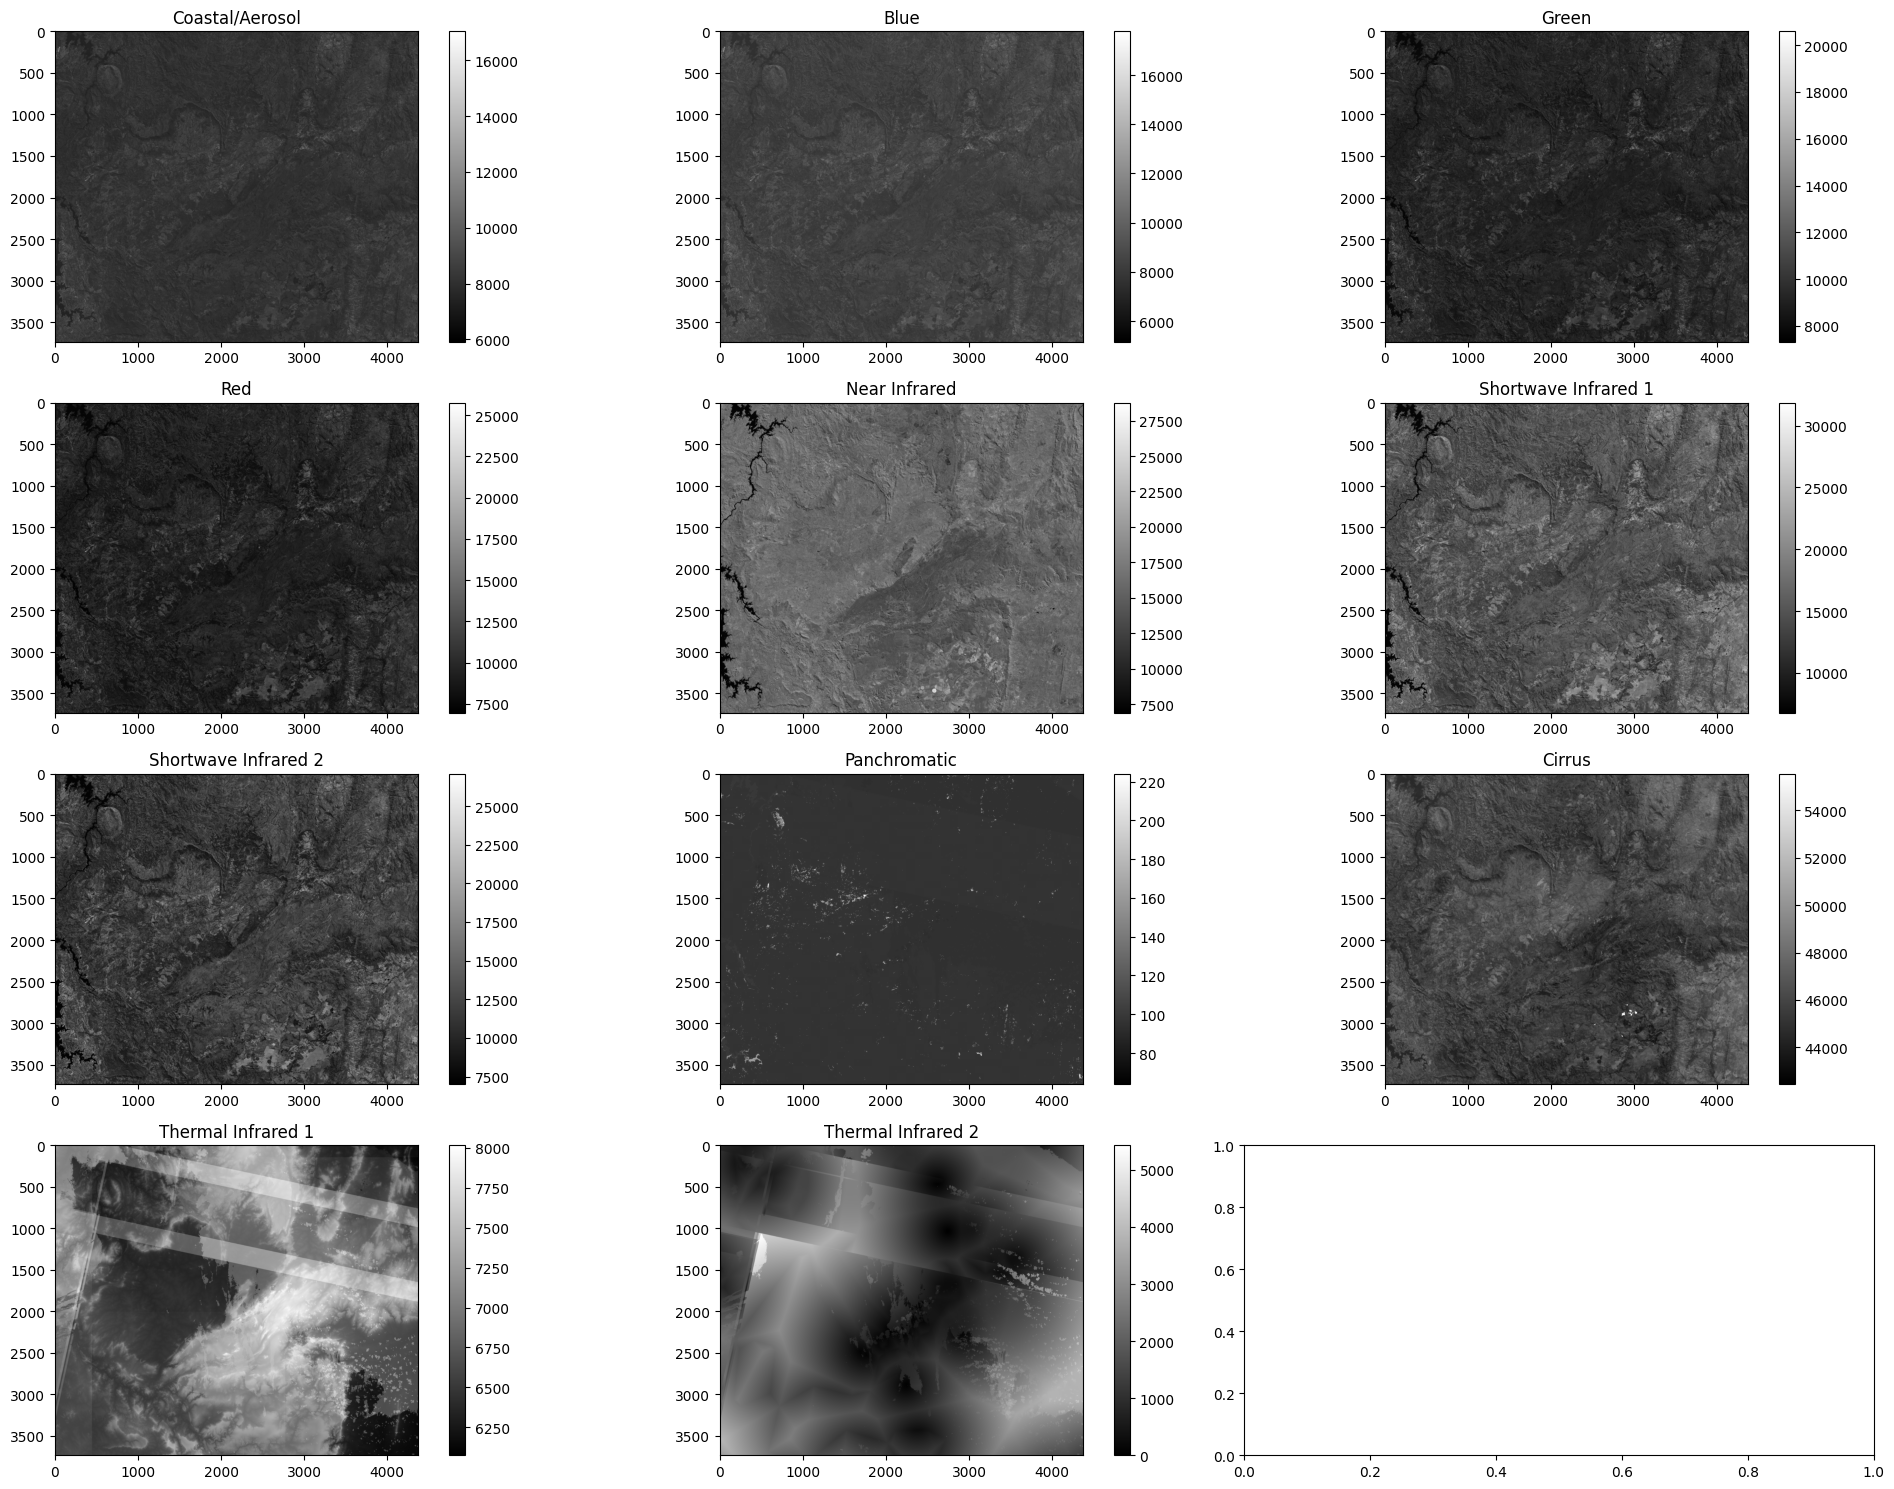

In [19]:
# We use gdal to open a specific geospatial file
ds = gdal.Open('/content/drive/MyDrive/deforestation_apa_alto_paraiso/2013api.tif')

# We create a dictionary mapping band numbers to their descriptive names
band_names = {
    1: "Coastal/Aerosol",
    2: "Blue",
    3: "Green",
    4: "Red",
    5: "Near Infrared",
    6: "Shortwave Infrared 1",
    7: "Shortwave Infrared 2",
    8: "Panchromatic",
    9: "Cirrus",
    10: "Thermal Infrared 1",
    11: "Thermal Infrared 2",
}

# We create a grid of subplots with 4 rows and 3 columns and set the figure size
fig, axs = plt.subplots(4, 3, figsize=(20, 15))

# We iterate over each band and name in the band_names dictionary
for band, name in band_names.items():
    # Identify the appropriate subplot to plot on
    ax = axs[(band - 1) // 3, (band - 1) % 3]
    # Read the current band's data as an array and display it as an image
    im = ax.imshow(ds.GetRasterBand(band).ReadAsArray())
    # Add a colorbar to the image
    fig.colorbar(im, ax=ax)
    # Set the subplot title to the band's name
    ax.set_title(name)

# Use tight_layout to ensure subplots do not overlap
plt.tight_layout()

# Display the figure
plt.show()


# 3. Normalized Difference Vegetation Index (NDVI)

The **Normalized Difference Vegetation Index** or NDVI is an index used to demonstrate the difference between visible and near-infrared reflectance of vegetation cover and **can be used to estimate the density of green in a land area**.

NDVI is calculated using the following formula:

$$
NDVI = \frac{(NIR - RED)}{(NIR + RED)}
$$

where `RED` and `NIR` represent spectral reflectance measurements acquired in the red (visible) and near-infrared regions, respectively. The NDVI index for a vegetated area should range between 0.3 (light vegetation) to 0.8 (dense vegetation). Clouds will have a negative index, while soil and water bodies will have low positive values. We'll use this information to estimate vegetation in a given region.

In normalized values (i.e., between 0 and 255), the range of interest corresponds to intensities between 165 and 230.

**Near-Infrared Region (NIR)**

The **NIR** region has a wavelength of 0.76 - 0.90 µm. Plant life absorbs visible light from 0.4 µm (blue light) to 0.7 µm (red light) for photosynthesis, with maximum absorption at both ends of this spectrum. We see plants as green because they typically don't absorb green light wavelengths (~0.5 µm) in the middle of this range. However, this makes the green channel less precise for vegetation detection as it falls within the full range of wavelengths used for photosynthesis. On the other hand, plants strongly reflect near-infrared light (0.7 to 1.1 µm). This fact is exploited in NDVI calculations.


In [22]:
threshold_lim_s = 150
threshold_lim_i = 255

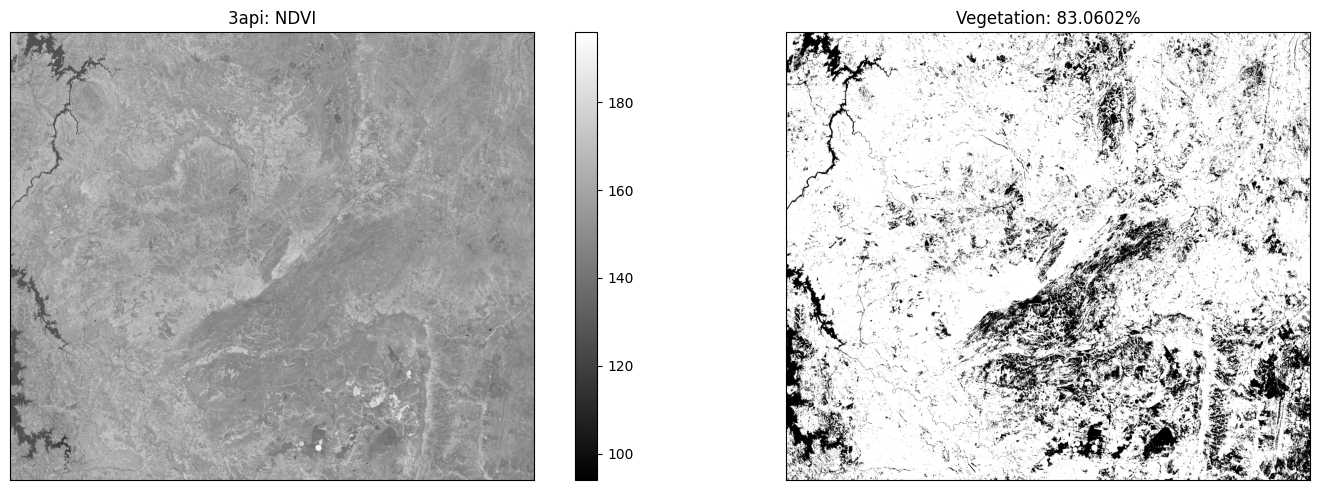

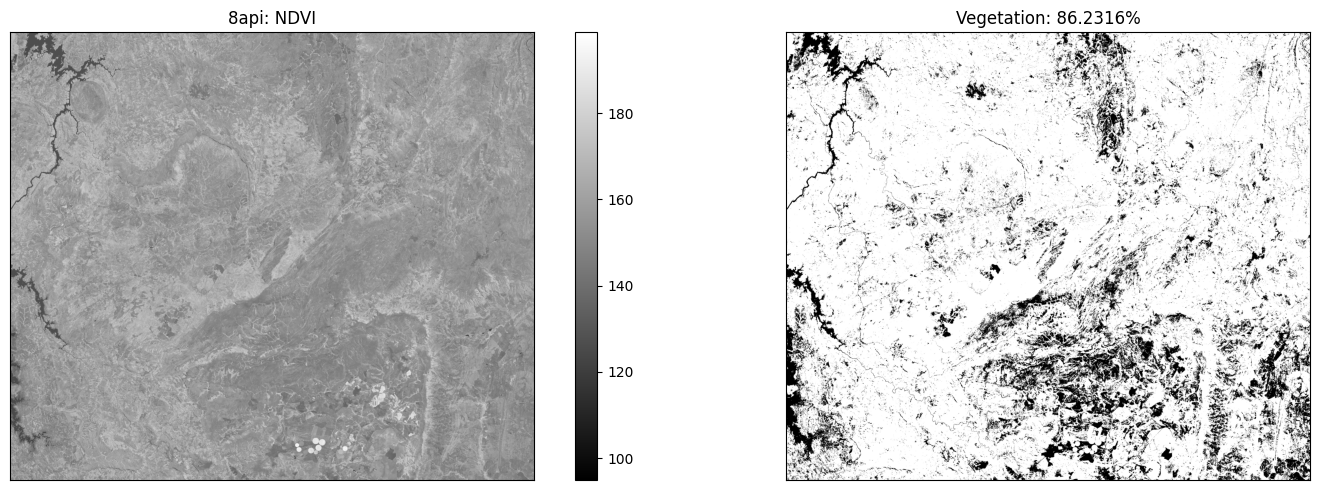

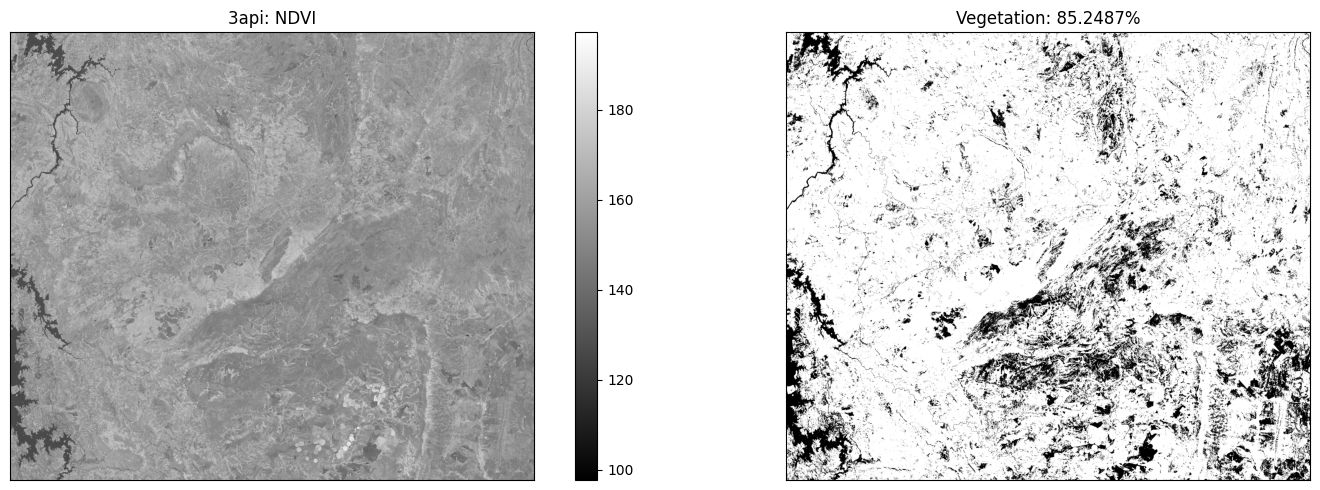

In [23]:
files = [
    "/content/drive/MyDrive/deforestation_apa_alto_paraiso/2013api.tif"
    ,"/content/drive/MyDrive/deforestation_apa_alto_paraiso/2018api.tif"
    ,"/content/drive/MyDrive/deforestation_apa_alto_paraiso/2023api.tif"
]

analyzer = NDVIAnalyzer()
for file in files:
    analyzer.plot_NDVI(file)

# 4. Results
The analyzed area corresponds to a cerrado region, and the vegetation coverage percentages do not show, at first glance, intense deforestation between 2013 and 2023.

However, it is important to consider that this analysis used satellite images covering a large area — approximately 14,000 square kilometers — belonging to the Pouso Alto Environmental Protection Area (APA) in Chapada dos Veadeiros.

The period chosen for the analysis was at the beginning of the dry season (June), when the cerrado vegetation has not yet developed the typical yellowish coloration seen during the peak dry season, which may influence the interpretation of vegetation indices.

For a more accurate assessment, it is recommended to:

Analyze smaller sub-areas within the APA to detect local variations in deforestation or degradation.

Conduct analyses in different periods of the year, including the rainy season and peak dry season, to capture seasonal vegetation variations.

Use other vegetation and environmental quality indices, such as EVI (Enhanced Vegetation Index), NDMI (Normalized Difference Moisture Index), and indices specifically suited for cerrado vegetation.

Explore data from other satellites with higher spatial or temporal resolution, such as Sentinel-2, which can provide more detailed and frequent images, enabling finer monitoring.